In [175]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [176]:
train, test = pd.read_csv('./data/train.csv'), pd.read_csv('./data/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [177]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- `Age`, `Cabin`, and `Embarked` having missing values 

In [178]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [179]:
(train['Survived'].value_counts() / len(train)) * 100


0    61.616162
1    38.383838
Name: Survived, dtype: float64

- Only about 38% of the passengers survived

In [180]:
train['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

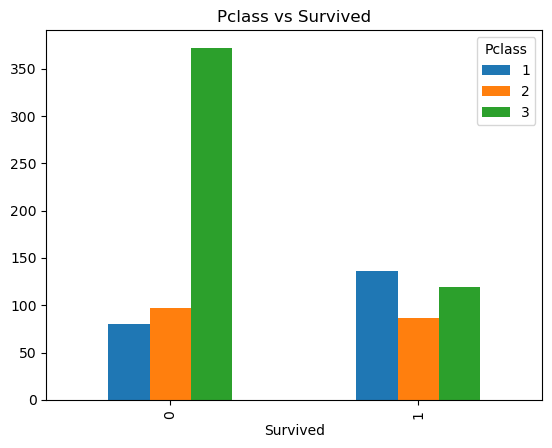

In [181]:
p_class_survived = pd.crosstab(train['Survived'], train['Pclass'])
p_class_survived.plot(kind = 'bar')
plt.title("Pclass vs Survived")
plt.show()

In [182]:
train['Sex'].value_counts() / len(train)

male      0.647587
female    0.352413
Name: Sex, dtype: float64

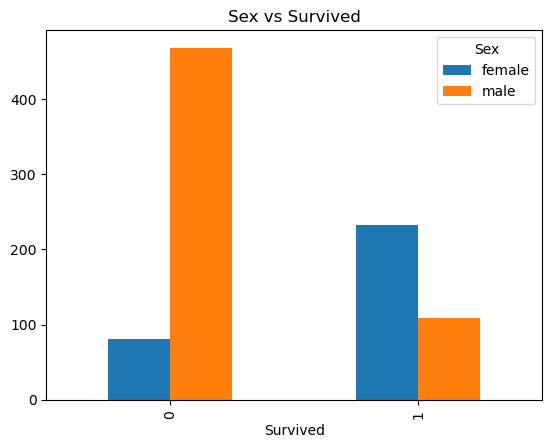

In [183]:
sex_survived = pd.crosstab(train['Survived'], train['Sex'])
sex_survived.plot(kind = 'bar')
plt.title("Sex vs Survived")
plt.show()


- Most of those who survived were females even though the number of males is almost double 

In [184]:
train['Cabin'].value_counts()

B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: Cabin, Length: 147, dtype: int64

In [185]:
train['Age'].value_counts().sort_index(ascending=False)

80.00    1
74.00    1
71.00    2
70.50    1
70.00    2
        ..
0.92     1
0.83     2
0.75     2
0.67     1
0.42     1
Name: Age, Length: 88, dtype: int64

In [186]:
ages = train['Age'].dropna()
bins = np.arange(0, 81, 20)
age_cat = pd.cut(ages, bins)
age_cat.value_counts()

(20, 40]    385
(0, 20]     179
(40, 60]    128
(60, 80]     22
Name: Age, dtype: int64

<Axes: xlabel='Survived'>

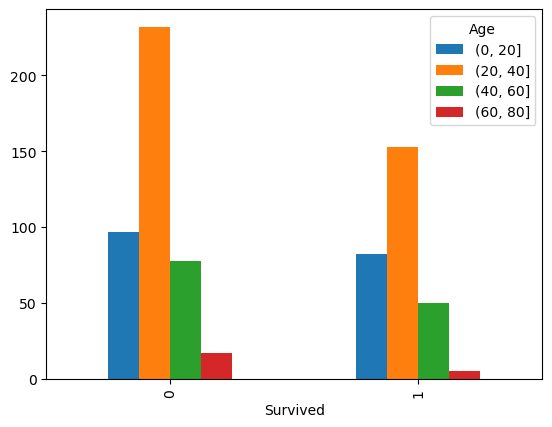

In [187]:
# only get non null ages for visualization and deal with them later 
ages = train['Age'].dropna()
bins = np.arange(0, 81, 20)
age_cat = pd.cut(ages, bins)
age_survived = pd.crosstab(train['Survived'], age_cat)
age_survived.plot(kind='bar')


In [188]:
train['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

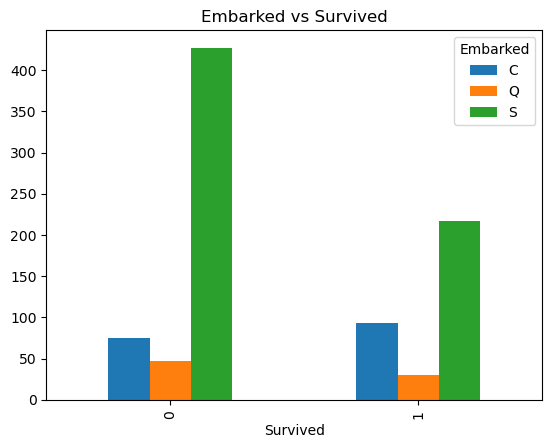

In [189]:
embarked_survived = pd.crosstab(train['Survived'], train['Embarked'])
embarked_survived.plot(kind = 'bar')
plt.title("Embarked vs Survived")
plt.show()

<Axes: xlabel='Survived'>

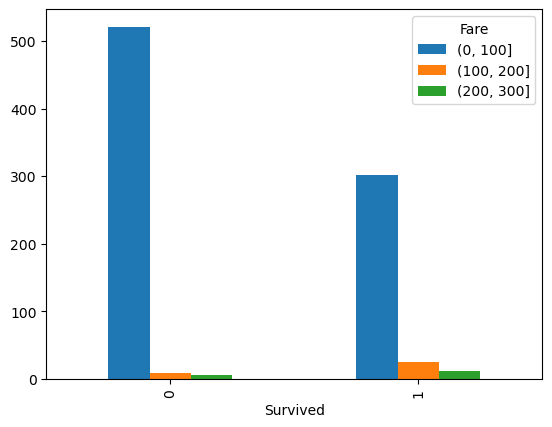

In [190]:
bins = np.arange(int(train['Fare'].min()), int(train['Fare'].max())+1, 100)
fare_cat = pd.cut(train['Fare'], bins)
fare_survived = pd.crosstab(train['Survived'], fare_cat)
fare_survived.plot(kind = 'bar')

In [191]:
train['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [192]:
# stratisfy on pclass

<Axes: xlabel='Survived'>

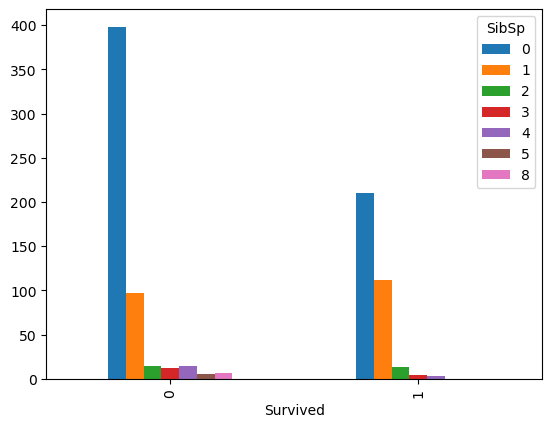

In [193]:
# SibSp	Parch
sibsp_survived = pd.crosstab(train['Survived'], train['SibSp'])
sibsp_survived.plot(kind = 'bar')

<Axes: xlabel='Survived'>

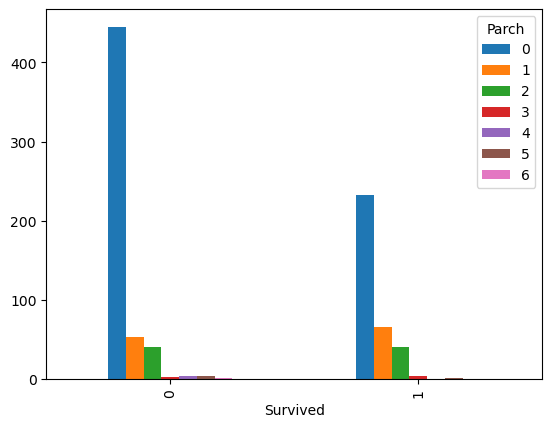

In [194]:
parch_survived = pd.crosstab(train['Survived'], train['Parch'])
parch_survived.plot(kind = 'bar')

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

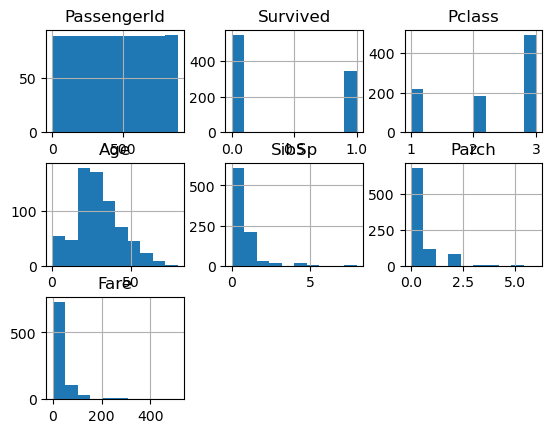

In [195]:
train.hist()
# log on Fare 

In [196]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [197]:
train_filtered = train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)
train_filtered.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [198]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(train_filtered, test_size=0.1, stratify= train_filtered['Sex'], random_state=42)
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
214,0,3,male,NaN,1,0,7.7500,Q
890,0,3,male,32.0,0,0,7.7500,Q
840,0,3,male,20.0,0,0,7.9250,S
9,1,2,female,14.0,1,0,30.0708,C
675,0,3,male,18.0,0,0,7.7750,S
...,...,...,...,...,...,...,...,...
834,0,3,male,18.0,0,0,8.3000,S
674,0,2,male,NaN,0,0,0.0000,S
728,0,2,male,25.0,1,0,26.0000,S
709,1,3,male,NaN,1,1,15.2458,C


In [199]:
train_data.corr()

/var/folders/sr/ng7767n515v9q0pk5vjn_tgh0000gn/T/ipykernel_12605/1402113604.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  train_data.corr()


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.321606,-0.076497,-0.030093,0.080216,0.256008
Pclass,-0.321606,1.000000,-0.383262,0.078769,0.008480,-0.550764
Age,-0.076497,-0.383262,1.000000,-0.319508,-0.171888,0.091259
SibSp,-0.030093,0.078769,-0.319508,1.000000,0.417869,0.160727
Parch,0.080216,0.008480,-0.171888,0.417869,1.000000,0.225094
Fare,0.256008,-0.550764,0.091259,0.160727,0.225094,1.000000


- `Pclass`, `Fare`, and `Sex` are the most effective features.

In [200]:
train_data.corr()['Survived'].sort_values(ascending = False)

/var/folders/sr/ng7767n515v9q0pk5vjn_tgh0000gn/T/ipykernel_12605/1379672646.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  train_data.corr()['Survived'].sort_values(ascending = False)


Survived    1.000000
Fare        0.256008
Parch       0.080216
SibSp      -0.030093
Age        -0.076497
Pclass     -0.321606
Name: Survived, dtype: float64

In [201]:
train_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
214,0,3,male,NaN,1,0,7.7500,Q
890,0,3,male,32.0,0,0,7.7500,Q
840,0,3,male,20.0,0,0,7.9250,S
9,1,2,female,14.0,1,0,30.0708,C
675,0,3,male,18.0,0,0,7.7750,S
...,...,...,...,...,...,...,...,...
834,0,3,male,18.0,0,0,8.3000,S
674,0,2,male,NaN,0,0,0.0000,S
728,0,2,male,25.0,1,0,26.0000,S
709,1,3,male,NaN,1,1,15.2458,C


In [202]:
labels = train_data['Survived'].copy()
train_data = train_data.drop('Survived', axis = 1, inplace=False)

- Prepare the data for the ML Model

In [203]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# fill missing values for age 
numerical_imputer = SimpleImputer(strategy='median') # age isn't that important correlation wise 
categorical_imputer = SimpleImputer(strategy='most_frequent')
# conduct one-hont encoding over the Sex column 
encoder = OneHotEncoder()
# standerdize the columns 
standerdizer = StandardScaler()

In [204]:
train_data_cat = train_data[['Sex']]
sex_cat = encoder.fit_transform(train_data_cat)

In [205]:
encoder.get_feature_names_out()

array(['Sex_female', 'Sex_male'], dtype=object)

In [206]:
sex_cat.toarray()

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

- Prepare a `Pipeline`

In [207]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector

numerical_pipeline = Pipeline([
    ("numerical_imputer", numerical_imputer),
    ("standerdizer", standerdizer)
])

categorical_pipeline = Pipeline([
    ("categorical_imputer", categorical_imputer),
    ("encoder", encoder)
])

preprocessing = ColumnTransformer([
    ("numerical", numerical_pipeline, make_column_selector(dtype_include=np.number)),
    ("categorical", categorical_pipeline, make_column_selector(dtype_include=object)),
]) 

In [208]:
train_data_preprocessed = preprocessing.fit_transform(train_data)
train_data_preprocessed

array([[ 0.81566782, -0.11148634,  0.41347427, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81566782,  0.19372602, -0.48650641, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81566782, -0.72191108, -0.48650641, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.37875617, -0.34039562,  0.41347427, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.81566782, -0.11148634,  0.41347427, ...,  1.        ,
         0.        ,  0.        ],
       [-0.37875617, -1.02712344, -0.48650641, ...,  0.        ,
         0.        ,  1.        ]])

In [209]:
preprocessing.get_feature_names_out()

array(['numerical__Pclass', 'numerical__Age', 'numerical__SibSp',
       'numerical__Parch', 'numerical__Fare', 'categorical__Sex_female',
       'categorical__Sex_male', 'categorical__Embarked_C',
       'categorical__Embarked_Q', 'categorical__Embarked_S'], dtype=object)

In [210]:
train_data_preprocessed = pd.DataFrame(train_data_preprocessed, columns=preprocessing.get_feature_names_out(), index = train_data.index)
train_data_preprocessed.head()

,numerical__Pclass,numerical__Age,numerical__SibSp,numerical__Parch,numerical__Fare,categorical__Sex_female,categorical__Sex_male,categorical__Embarked_C,categorical__Embarked_Q,categorical__Embarked_S
214,0.815668,-0.111486,0.413474,-0.468823,-0.490225,0.0,1.0,0.0,1.0,0.0
890,0.815668,0.193726,-0.486506,-0.468823,-0.490225,0.0,1.0,0.0,1.0,0.0
840,0.815668,-0.721911,-0.486506,-0.468823,-0.486768,0.0,1.0,0.0,0.0,1.0
9,-0.378756,-1.179730,0.413474,-0.468823,-0.049328,1.0,0.0,1.0,0.0,0.0
675,0.815668,-0.874517,-0.486506,-0.468823,-0.489731,0.0,1.0,0.0,0.0,1.0


- Let's try to find some models 

In [211]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

logistic_reg = LogisticRegression()
cross_val_score(logistic_reg, train_data_preprocessed, labels, cv = 3, scoring = 'accuracy')

array([0.79026217, 0.80149813, 0.80898876])

In [212]:
from sklearn.ensemble import RandomForestClassifier
random_forest_clf = RandomForestClassifier()
cross_val_score(random_forest_clf, train_data_preprocessed, labels, cv = 3, scoring = 'accuracy')

array([0.79026217, 0.79775281, 0.80149813])

In [213]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
cross_val_score(knn, train_data_preprocessed, labels, cv = 3, scoring = 'accuracy')



array([0.76404494, 0.81273408, 0.82022472])

In [214]:
from sklearn.svm import SVC
svc = make_pipeline(preprocessing, SVC())
svc.fit(train_data, labels)

,steps,"[('columntransformer', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [215]:
cross_val_score(svc, train_data, labels, cv = 3, scoring = 'accuracy')


array([0.81273408, 0.83146067, 0.84269663])

- Try grid search over `SVC`

In [216]:
from sklearn.model_selection import GridSearchCV

grid_params = [
    {"svc__C": [0.5, 1, 2, 4, 8, 16], "svc__kernel": ['linear', 'poly', 'sigmoid', 'rbf']}
]

grid_search = GridSearchCV (svc, grid_params, cv = 3, scoring = 'accuracy')
grid_search.fit(train_data, labels)

,estimator,"Pipeline(step...svc', SVC())])"
,param_grid,"[{'svc__C': [0.5, 1, ...], 'svc__kernel': ['linear', 'poly', ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [217]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svc__C,param_svc__kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007225,0.001700,0.002719,0.000088,0.5,linear,"{'svc__C': 0.5, 'svc__kernel': 'linear'}",0.797753,0.801498,0.786517,0.795256,0.006366,13
1,0.006410,0.000365,0.002887,0.000235,0.5,poly,"{'svc__C': 0.5, 'svc__kernel': 'poly'}",0.812734,0.812734,0.812734,0.812734,0.000000,9
2,0.006983,0.000110,0.003281,0.000120,0.5,sigmoid,"{'svc__C': 0.5, 'svc__kernel': 'sigmoid'}",0.707865,0.692884,0.674157,0.691635,0.013789,19
3,0.006457,0.000462,0.004421,0.000132,0.5,rbf,"{'svc__C': 0.5, 'svc__kernel': 'rbf'}",0.805243,0.827715,0.842697,0.825218,0.015392,3
4,0.006624,0.001144,0.002583,0.000141,1.0,linear,"{'svc__C': 1, 'svc__kernel': 'linear'}",0.797753,0.801498,0.786517,0.795256,0.006366,13
5,0.006188,0.000058,0.002823,0.000184,1.0,poly,"{'svc__C': 1, 'svc__kernel': 'poly'}",0.816479,0.823970,0.827715,0.822722,0.004671,4
6,0.006438,0.000103,0.003060,0.000095,1.0,sigmoid,"{'svc__C': 1, 'svc__kernel': 'sigmoid'}",0.707865,0.670412,0.692884,0.690387,0.015392,20
7,0.006256,0.000279,0.004125,0.000034,1.0,rbf,"{'svc__C': 1, 'svc__kernel': 'rbf'}",0.812734,0.831461,0.842697,0.828964,0.012359,1
8,0.007935,0.001494,0.002945,0.000340,2.0,linear,"{'svc__C': 2, 'svc__kernel': 'linear'}",0.797753,0.801498,0.786517,0.795256,0.006366,13
9,0.007391,0.000203,0.003184,0.000446,2.0,poly,"{'svc__C': 2, 'svc__kernel': 'poly'}",0.812734,0.823970,0.823970,0.820225,0.005297,5


In [218]:
grid_search.cv_results_

{'mean_fit_time': array([0.00722504, 0.00641036, 0.0069828 , 0.00645733, 0.0066239 ,
        0.00618776, 0.00643833, 0.00625626, 0.00793544, 0.00739129,
        0.00881298, 0.00691708, 0.01184765, 0.00802692, 0.00714095,
        0.0076534 , 0.01464693, 0.00883365, 0.00675956, 0.00673755,
        0.02276874, 0.01109163, 0.00661596, 0.00746902]),
 'std_fit_time': array([1.69983375e-03, 3.65109908e-04, 1.10389604e-04, 4.61792272e-04,
        1.14352593e-03, 5.75968277e-05, 1.03048017e-04, 2.78704781e-04,
        1.49409212e-03, 2.02959649e-04, 1.54037058e-03, 3.52580229e-04,
        3.42874995e-03, 7.11045093e-04, 3.72422455e-04, 8.58683356e-04,
        4.52926961e-03, 8.40287806e-04, 4.40332473e-04, 1.47027840e-04,
        9.33532484e-03, 5.98300560e-04, 5.39867635e-04, 4.34597520e-04]),
 'mean_score_time': array([0.002719  , 0.00288685, 0.00328135, 0.0044206 , 0.00258263,
        0.00282288, 0.00305963, 0.00412512, 0.00294534, 0.0031844 ,
        0.00488869, 0.00465624, 0.00292675, 0.00

In [220]:
grid_search.best_params_

{'svc__C': 1, 'svc__kernel': 'rbf'}

In [222]:
y_val = val_data['Survived']
val_data = val_data.drop('Survived', axis = 1)

In [223]:
y_predictions = svc.predict(val_data)

In [224]:
sum(y_val == y_predictions)/len(y_val)

0.7888888888888889

- Make predictions on the test set

In [226]:
test = pd.read_csv('./data/test.csv')

In [227]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [228]:
test_predictions = svc.predict(test)

In [236]:
test_predictions

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [235]:
test['PassengerId'].values

array([ 892,  893,  894,  895,  896,  897,  898,  899,  900,  901,  902,
        903,  904,  905,  906,  907,  908,  909,  910,  911,  912,  913,
        914,  915,  916,  917,  918,  919,  920,  921,  922,  923,  924,
        925,  926,  927,  928,  929,  930,  931,  932,  933,  934,  935,
        936,  937,  938,  939,  940,  941,  942,  943,  944,  945,  946,
        947,  948,  949,  950,  951,  952,  953,  954,  955,  956,  957,
        958,  959,  960,  961,  962,  963,  964,  965,  966,  967,  968,
        969,  970,  971,  972,  973,  974,  975,  976,  977,  978,  979,
        980,  981,  982,  983,  984,  985,  986,  987,  988,  989,  990,
        991,  992,  993,  994,  995,  996,  997,  998,  999, 1000, 1001,
       1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012,
       1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023,
       1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034,
       1035, 1036, 1037, 1038, 1039, 1040, 1041, 10

In [238]:
data = {'PassengerId': test['PassengerId'], 'Survived': test_predictions}
results_df = pd.DataFrame(data = data)
results_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [240]:
results_df.to_csv('./predictions.csv', index= False)

In [241]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
